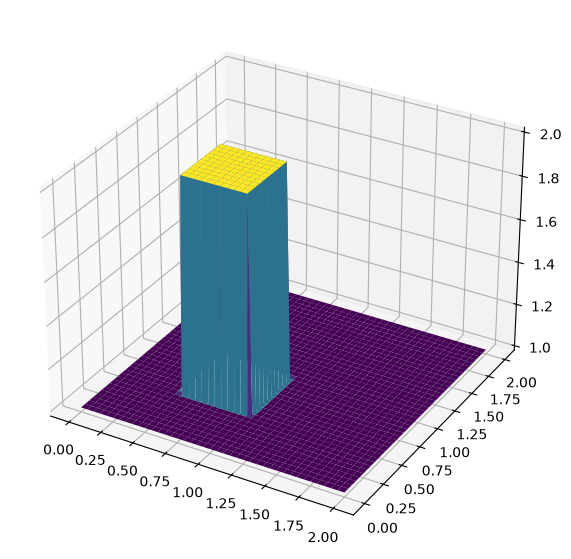

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import clear_output

nx = 81
ny = 81
nt = 100

cx = 1
cy = 1

dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
sigma = 0.2
dt = sigma * dx

x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)

u = np.ones((ny, nx))
u[int(.5 / dy):int(1 / dy + 1),int(.5 / dx):int(1 / dx + 1)] = 2 

fig = plt.figure(figsize=(11, 7), dpi=100)
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(x, y)
surf = ax.plot_surface(X, Y, u[:], cmap=cm.viridis)

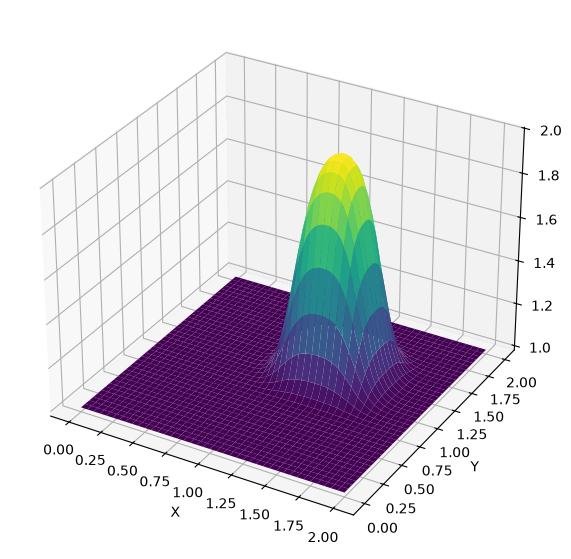

In [2]:
for n in range(nt):
    un = u.copy()
    for j in range(1, ny):
        for i in range(1, nx):
            u[j, i] = u[j, i] - cx * dt / dx * (un[j, i] - un[j, i-1]) - cy * dt / dy * (un[j, i] - un[j-1, i])
        
    u[0, :] = 1
    u[-1, :] = 1
    u[:, 0] = 1
    u[:, -1] = 1

    clear_output(True)
    fig = plt.figure(figsize=(11, 7), dpi=100)
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, u[:], cmap=cm.viridis)
    # ax.view_init(elev=30, azim=n*1)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('u')
    plt.pause(0.001)
